In [1]:
#Task 1 — Data Loading, Merging & Deep Exploration

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
df = pd.read_csv("train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [5]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [7]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales']

In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
print(df['Order Date'].dtype)

datetime64[ns]


In [9]:
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [10]:
weekly_sales = df.resample('W', on='Order Date')['Sales'].sum().reset_index()

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [11]:
monthly_sales = df.resample('M', on='Order Date')['Sales'].sum().reset_index()

monthly_sales.head()

C:\Users\hruth\AppData\Local\Temp\ipykernel_4492\1095333538.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='Order Date')['Sales'].sum().reset_index()


,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [12]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


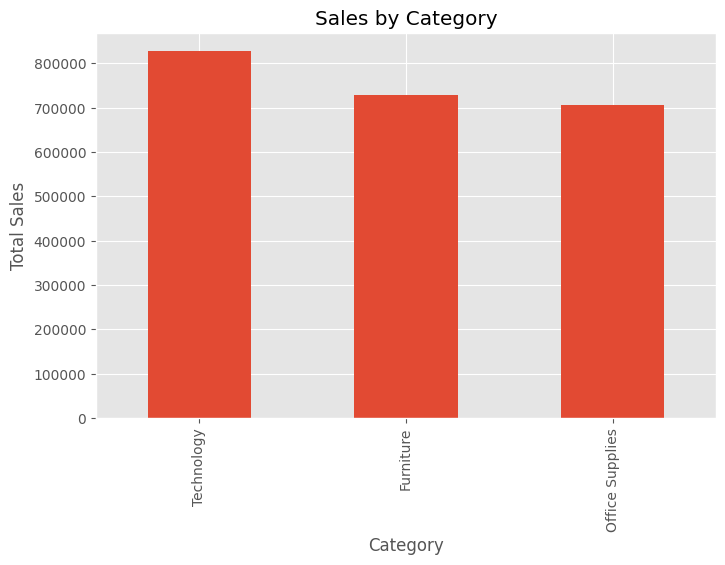

In [13]:
plt.figure(figsize=(8,5))

category_sales.plot(kind='bar')

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

In [14]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

print(region_sales)

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


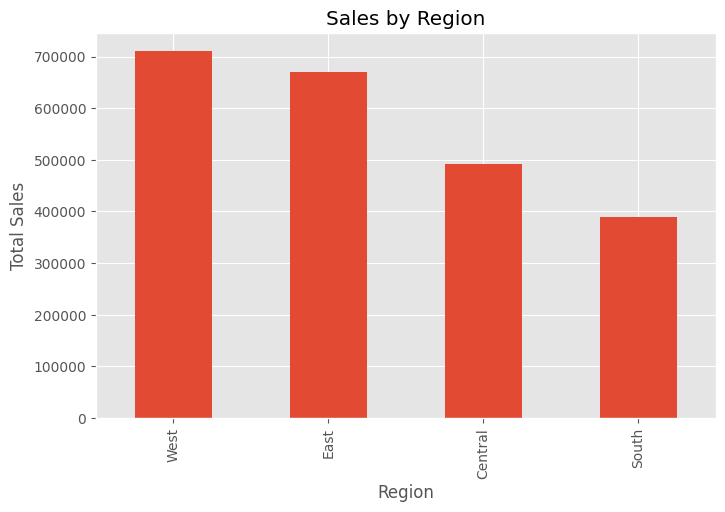

In [15]:
plt.figure(figsize=(8,5))

region_sales.plot(kind='bar')

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

In [16]:
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

df['Shipping Days'].describe()

count    9800.000000
mean        3.961122
std         1.749614
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping Days, dtype: float64

In [17]:
shipping_region = df.groupby('Region')['Shipping Days'].mean()

print(shipping_region)

Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Shipping Days, dtype: float64


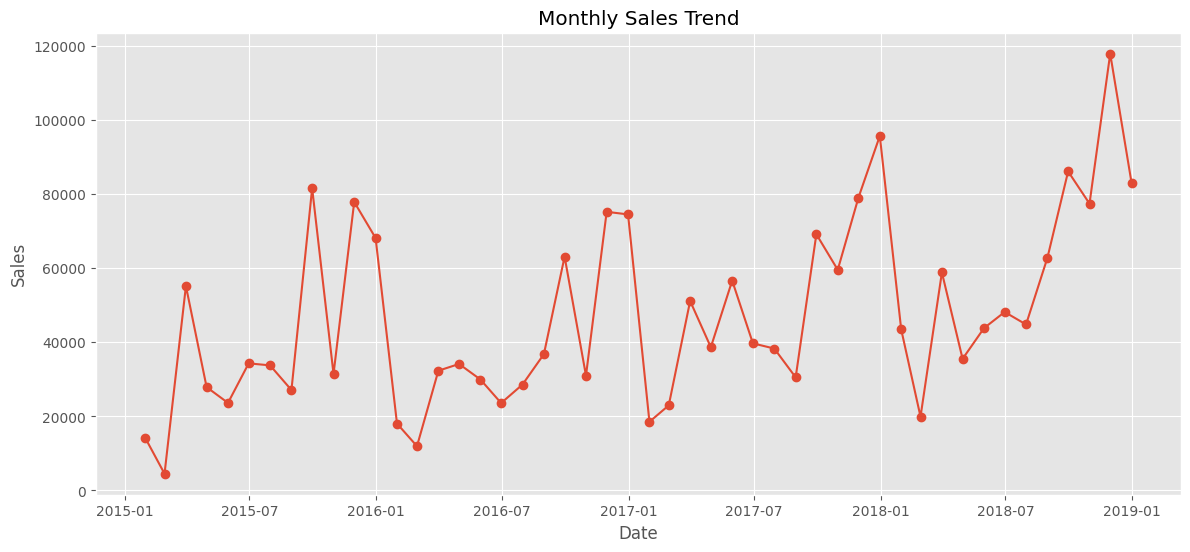

In [18]:
plt.figure(figsize=(14,6))

plt.plot(monthly_sales['Order Date'],
         monthly_sales['Sales'],
         marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

In [ ]:
## Task 1 Observations

- Technology generated the highest overall sales among all categories.
- The West region achieved the highest sales, while the South region had the lowest.
- The average shipping time is approximately 4 days and remains fairly consistent across all regions.
- Monthly sales show an upward trend over the four-year period with noticeable seasonal peaks, especially toward the end of each year.

In [19]:
#Task 2 — Time Series Analysis & Decomposition
monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()

C:\Users\hruth\AppData\Local\Temp\ipykernel_4492\1214477550.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()


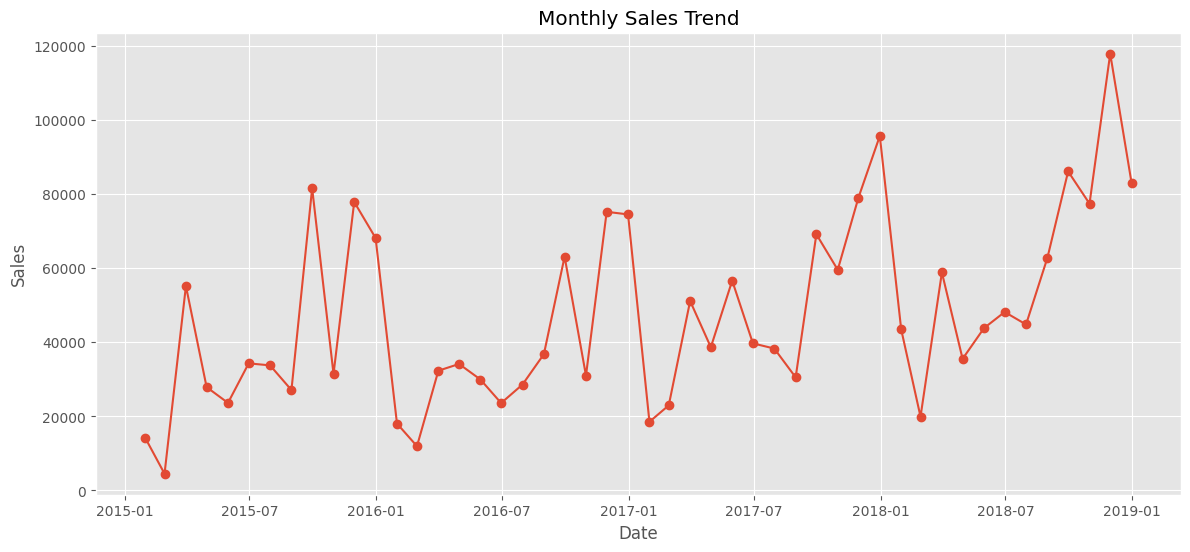

In [20]:
plt.figure(figsize=(14,6))
plt.plot(monthly_sales, marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

In [21]:
import statsmodels
print(statsmodels.__version__)

0.14.6


In [22]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [23]:
import sys
!{sys.executable} -m pip install statsmodels

In [24]:
import statsmodels
print(statsmodels.__version__)
print(statsmodels.__file__)

0.14.6
C:\Users\hruth\.conda\envs\tensorflow_env\lib\site-packages\statsmodels\__init__.py


In [25]:
from statsmodels.tsa.seasonal import seasonal_decompose

print("Statsmodels imported successfully!")

Statsmodels imported successfully!


In [26]:
print(type(monthly_sales))
monthly_sales.head()

<class 'pandas.core.series.Series'>


Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

In [27]:
print(monthly_sales.head())
print(monthly_sales.columns)

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64


AttributeError: 'Series' object has no attribute 'columns'

In [ ]:
print(monthly_sales.index)

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

decomposition = seasonal_decompose(
    monthly_sales['Sales'],
    model='additive',
    period=12
)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

In [ ]:
#Observations

Look at the four graphs (Observed, Trend, Seasonal, Residual) and write observations in a Markdown cell.

You can use something like this (adjust if your graphs look different):

Observations
Trend: The overall sales trend shows a gradual increase over the four-year period, indicating business growth.
Seasonality: Sales exhibit clear yearly seasonality, with higher sales during certain months, suggesting recurring customer purchasing patterns.
Residual: Residual values contain a few spikes, indicating unusual sales events that are not explained by trend or seasonality.
Business Insight: The presence of trend and seasonality suggests that forecasting models can effectively learn from historical sales data.

In [ ]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
result = adfuller(monthly_sales['Sales'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(key, ":", value)

In [ ]:
monthly_sales_diff = monthly_sales['Sales'].diff().dropna()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(monthly_sales_diff)
plt.title("Differenced Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Differenced Sales")
plt.grid(True)
plt.show()

In [ ]:
result_diff = adfuller(monthly_sales_diff)

print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])

In [ ]:
#ADF Test Interpretation

The Augmented Dickey-Fuller (ADF) test was performed to determine whether the monthly sales time series is stationary.

ADF Statistic: -8.7271
p-value: 3.27 × 10⁻¹⁴

Since the p-value is significantly less than 0.05, the null hypothesis is rejected. This indicates that the monthly sales series is stationary. Therefore, no differencing is required before applying forecasting models such as SARIMA.

In [28]:
#Task 3 — Sales Forecasting using 3 Different Models
from statsmodels.tsa.statespace.sarimax import SARIMAX

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [29]:
monthly_sales = monthly_sales.asfreq('ME')

In [32]:
train = monthly_sales[:-3]
test = monthly_sales[-3:]

print(train.shape)
print(test.shape)

(45,)
(3,)


In [47]:
sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_fit = sarima_model.fit()

sarima_forecast = sarima_fit.get_forecast(steps=3)

sarima_values = sarima_forecast.predicted_mean

confidence = sarima_forecast.conf_int()
print(sarima_values)

2018-10-31    66177.602433
2018-11-30    92049.249676
2018-12-31    99965.168714
Freq: ME, Name: predicted_mean, dtype: float64


C:\Users\hruth\.conda\envs\tensorflow_env\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [48]:
prophet_model = Prophet()

prophet_model.fit(train_prophet)

future = prophet_model.make_future_dataframe(
    periods=3,
    freq='ME'
)

prophet_forecast = prophet_model.predict(future)

08:47:00 - cmdstanpy - INFO - Chain [1] start processing
08:47:01 - cmdstanpy - INFO - Chain [1] done processing


In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, sarima_values)

rmse = np.sqrt(mean_squared_error(test, sarima_values))

mape = np.mean(np.abs((test - sarima_values) / test)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 18031.404668269082
RMSE: 19009.18206463229
MAPE: 18.966498062701262


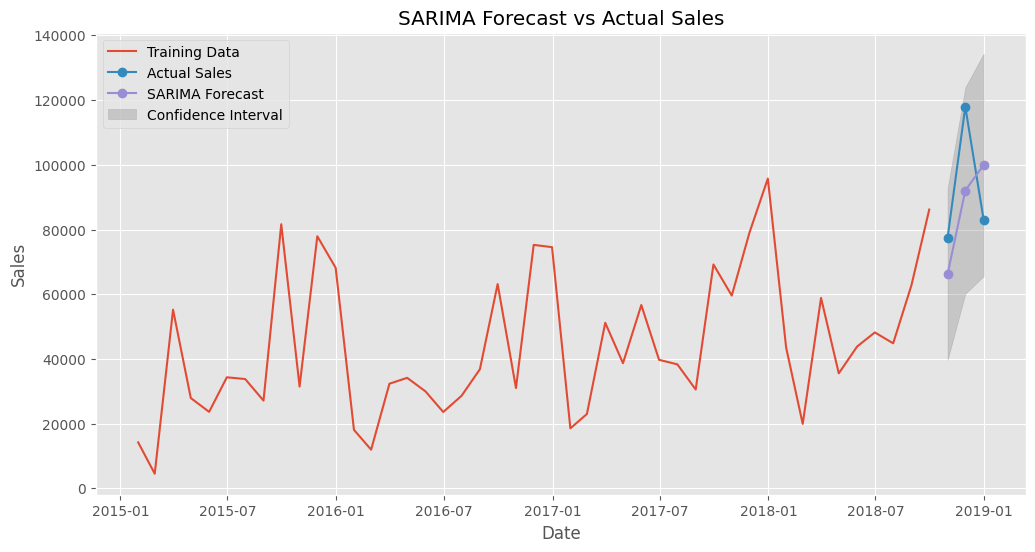

In [51]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual Sales', marker='o')

plt.plot(
    sarima_values.index,
    sarima_values,
    label='SARIMA Forecast',
    marker='o'
)

plt.fill_between(
    confidence.index,
    confidence.iloc[:, 0],
    confidence.iloc[:, 1],
    color='gray',
    alpha=0.3,
    label='Confidence Interval'
)

plt.title("SARIMA Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

forecast_test = prophet_forecast[['ds', 'yhat']].tail(3)

mae_prophet = mean_absolute_error(
    test_prophet['y'],
    forecast_test['yhat']
)

rmse_prophet = np.sqrt(
    mean_squared_error(
        test_prophet['y'],
        forecast_test['yhat']
    )
)

mape_prophet = np.mean(
    np.abs(
        (test_prophet['y'] - forecast_test['yhat'])
        / test_prophet['y']
    )
) * 100

print("MAE:", mae_prophet)
print("RMSE:", rmse_prophet)
print("MAPE:", mape_prophet)

MAE: 20250.794412605526
RMSE: 22318.411332860545
MAPE: 21.864628273960825


In [50]:
#Next: Model 2 – Prophet
import sys
!"{sys.executable}" -m pip install prophet

  Using cached prophet-1.3.0-py3-none-win_amd64.whl.metadata (3.6 kB)
  Using cached cmdstanpy-1.3.0-py3-none-any.whl.metadata (4.2 kB)
  Using cached holidays-0.100-py3-none-any.whl.metadata (53 kB)
  Using cached importlib_resources-7.1.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached stanio-0.5.1-py3-none-any.whl.metadata (1.6 kB)
Using cached prophet-1.3.0-py3-none-win_amd64.whl (12.1 MB)
Using cached holidays-0.100-py3-none-any.whl (1.5 MB)
Using cached cmdstanpy-1.3.0-py3-none-any.whl (99 kB)
Using cached stanio-0.5.1-py3-none-any.whl (8.1 kB)
   ---------------------------------------- 0.0/676.6 kB ? eta -:--:--
   ------------------------------ --------- 524.3/676.6 kB 8.5 MB/s eta 0:00:01
   ---------------------------------------- 676.6/676.6 kB 4.4 MB/s eta 0:00:00
Using cached importlib_resources-7.1.0-py3-none-any.whl (37 kB)

   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   --------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
%pip install ipywidgets


   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ---------------------------------- ----- 786.4/914.9 kB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 914.9/914.9 kB 3.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   -------------- ------------------------- 0.8/2.2 MB 3.0 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 5.2 MB/s eta 0:00:00

   ---------------------------------------- 0/3 [widgetsnbextension]
   ------------- -------------------------- 1/3 [jupyterlab_widgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------

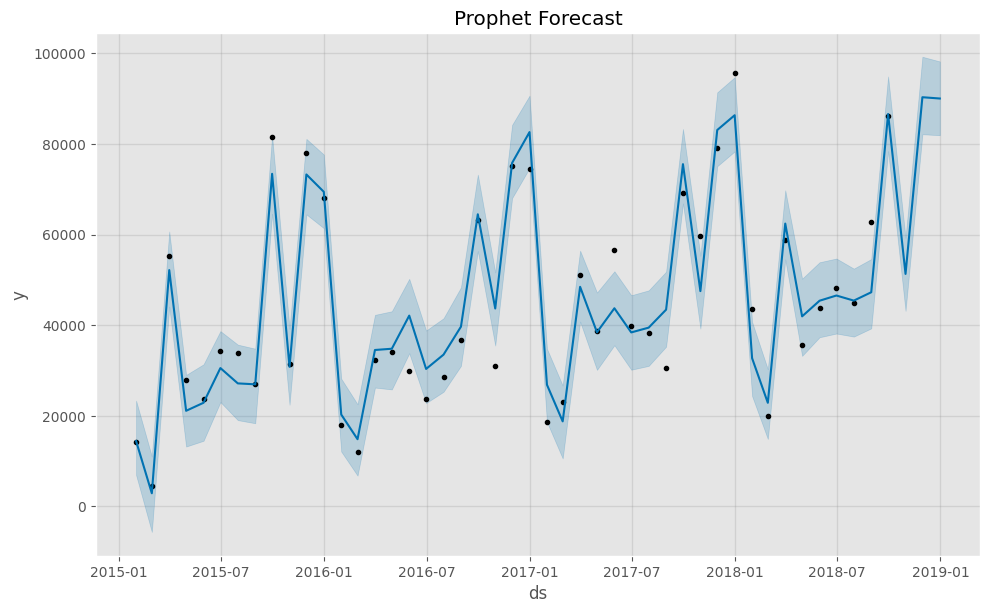

In [54]:
fig = prophet_model.plot(prophet_forecast)

plt.title("Prophet Forecast")

plt.show()

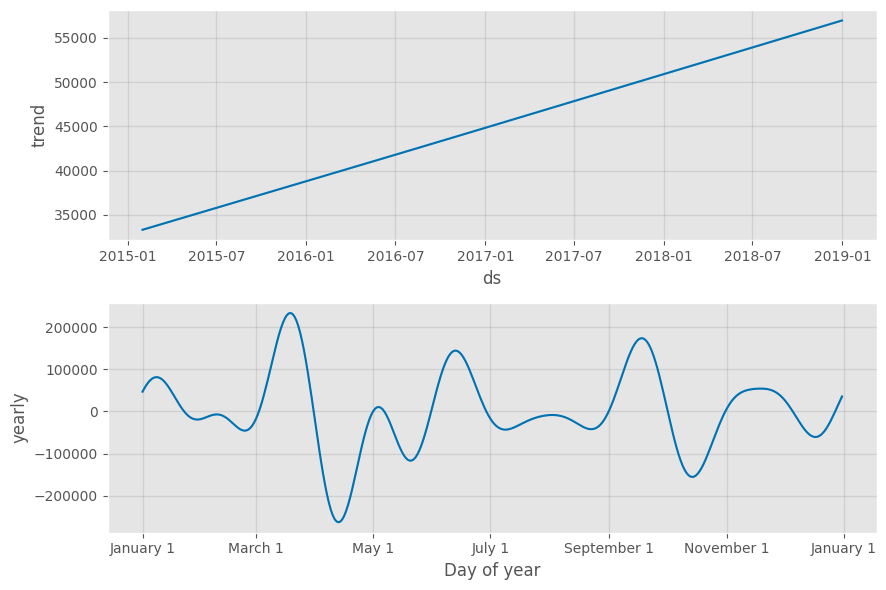

In [55]:
prophet_model.plot_components(prophet_forecast)

plt.show()

In [56]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
    --------------------------------------- 1.0/69.5 MB 6.3 MB/s eta 0:00:11
   - -------------------------------------- 1.8/69.5 MB 4.8 MB/s eta 0:00:15
   - -------------------------------------- 2.6/69.5 MB 4.4 MB/s eta 0:00:16
   - -------------------------------------- 3.4/69.5 MB 4.3 MB/s eta 0:00:16
   -- ------------------------------------- 4.5/69.5 MB 4.2 MB/s eta 0:00:16
   --- ------------------------------------ 5.2/69.5 MB 4.1 MB/s eta 0:00:16
   --- ------------------------------------ 6.0/69.5 MB 4.1 MB/s eta 0:00:16
   ---- ----------------------------------- 7.1/69.5 MB 4.1 MB/s eta 0:00:16
   ---- ----------------------------------- 7.9/69.5 MB 4.1 MB/s eta 0:00:16
   ---- ----------------------------------- 8.7/69.5 MB 4.0 MB/s eta 0:00:16
   ----- ---------------------------------- 9.4/69.5 MB 4.0 MB/s eta 0:00:15
   --

In [58]:
import sys
!"{sys.executable}" -m pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 5.0 MB/s eta 0:00:20
    --------------------------------------- 1.8/101.7 MB 4.4 MB/s eta 0:00:23
   - -------------------------------------- 2.6/101.7 MB 4.2 MB/s eta 0:00:24
   - -------------------------------------- 3.4/101.7 MB 4.1 MB/s eta 0:00:24
   - -------------------------------------- 3.9/101.7 MB 3.7 MB/s eta 0:00:27
   - -------------------------------------- 5.0/101.7 MB 4.0 MB/s eta 0:00:25
   -- ------------------------------------- 6.0/101.7 MB 4.0 MB/s eta 0:00:24
   -- ------------------------------------- 6.6/101.7 MB 4.0 MB/s eta 0:00:24
   -- ------------------------------------- 7.6/101.7 MB 4.0 MB/s eta 0:00:24
   --- ------------------------------------ 8.4/101.7 MB 4.0 MB/s eta 0:00:24
   --- ------------------------------------ 9.2/101.7 MB 4.0 MB/s eta 0:00:24
   --- ------------------------------------ 10.0/101.7 MB 4.0 MB/s eta 

In [59]:
from xgboost import XGBRegressor
xgb_df = monthly_sales.to_frame()

xgb_df['lag_1'] = xgb_df['Sales'].shift(1)
xgb_df['lag_2'] = xgb_df['Sales'].shift(2)
xgb_df['lag_3'] = xgb_df['Sales'].shift(3)

xgb_df['rolling_mean'] = xgb_df['Sales'].rolling(3).mean()

xgb_df['month'] = xgb_df.index.month
xgb_df['quarter'] = xgb_df.index.quarter

xgb_df = xgb_df.dropna()

xgb_df.head()

,Sales,lag_1,lag_2,lag_3,rolling_mean,month,quarter
Order Date,,,,,,,
2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2
2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2
2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2
2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3
2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3


In [61]:
X = xgb_df.drop('Sales', axis=1)

y = xgb_df['Sales']
X_train = X[:-3]
X_test = X[-3:]

y_train = y[:-3]
y_test = y[-3:]

In [62]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [63]:
xgb_predictions = xgb_model.predict(X_test)

print(xgb_predictions)

[86465.82 86506.77 84327.28]


In [64]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_xgb = mean_absolute_error(y_test, xgb_predictions)

rmse_xgb = np.sqrt(
    mean_squared_error(y_test, xgb_predictions)
)

mape_xgb = np.mean(
    np.abs(
        (y_test - xgb_predictions) / y_test
    )
) * 100

print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("MAPE:", mape_xgb)

MAE : 13915.321041666664
RMSE: 18893.847269098238
MAPE: 13.285400568532047


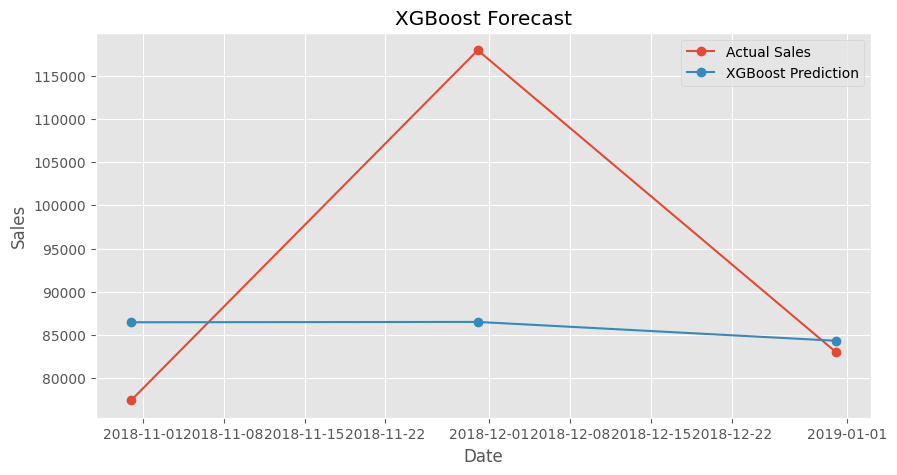

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    y_test.index,
    y_test,
    label='Actual Sales',
    marker='o'
)

plt.plot(
    y_test.index,
    xgb_predictions,
    label='XGBoost Prediction',
    marker='o'
)

plt.title("XGBoost Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [66]:
comparison = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE': [
        mae,
        mae_prophet,
        mae_xgb
    ],
    'RMSE': [
        rmse,
        rmse_prophet,
        rmse_xgb
    ],
    'MAPE': [
        mape,
        mape_prophet,
        mape_xgb
    ]
})

print(comparison)

     Model           MAE          RMSE       MAPE
0   SARIMA  18031.404668  19009.182065  18.966498
1  Prophet  20250.794413  22318.411333  21.864628
2  XGBoost  13915.321042  18893.847269  13.285401


In [67]:
#Task 4 — Product Category & Region Level Forecasting
print(comparison)

     Model           MAE          RMSE       MAPE
0   SARIMA  18031.404668  19009.182065  18.966498
1  Prophet  20250.794413  22318.411333  21.864628
2  XGBoost  13915.321042  18893.847269  13.285401


In [68]:
furniture = df[df['Category'] == 'Furniture']

furniture_sales = furniture.groupby(
    pd.Grouper(key='Order Date', freq='ME')
)['Sales'].sum()

In [69]:
technology = df[df['Category'] == 'Technology']

technology_sales = technology.groupby(
    pd.Grouper(key='Order Date', freq='ME')
)['Sales'].sum()

In [70]:
office = df[df['Category'] == 'Office Supplies']

office_sales = office.groupby(
    pd.Grouper(key='Order Date', freq='ME')
)['Sales'].sum()

In [71]:
west = df[df['Region'] == 'West']

west_sales = west.groupby(
    pd.Grouper(key='Order Date', freq='ME')
)['Sales'].sum()

In [72]:
east = df[df['Region'] == 'East']

east_sales = east.groupby(
    pd.Grouper(key='Order Date', freq='ME')
)['Sales'].sum()

In [73]:
from prophet import Prophet

furniture_df = furniture_sales.reset_index()
furniture_df.columns = ['ds', 'y']

model = Prophet()

model.fit(furniture_df)

future = model.make_future_dataframe(
    periods=3,
    freq='ME'
)

forecast = model.predict(future)

forecast[['ds', 'yhat']].tail(3)

08:58:11 - cmdstanpy - INFO - Chain [1] start processing
08:58:12 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat
48,2019-01-31,12691.392668
49,2019-02-28,6772.162417
50,2019-03-31,17201.015648


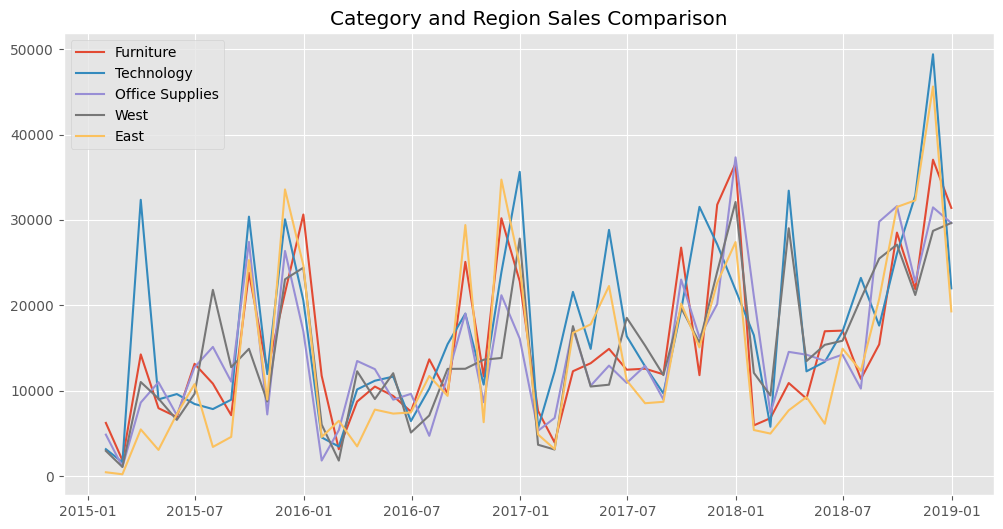

In [74]:
plt.figure(figsize=(12, 6))

plt.plot(
    furniture_sales.index,
    furniture_sales,
    label='Furniture'
)

plt.plot(
    technology_sales.index,
    technology_sales,
    label='Technology'
)

plt.plot(
    office_sales.index,
    office_sales,
    label='Office Supplies'
)

plt.plot(
    west_sales.index,
    west_sales,
    label='West'
)

plt.plot(
    east_sales.index,
    east_sales,
    label='East'
)

plt.legend()

plt.title("Category and Region Sales Comparison")

plt.show()

In [ ]:
#Observation
Technology shows the strongest growth trend, while Office Supplies exhibits relatively stable demand. The West region is expected to generate higher 
sales than the East region over the next three months.

In [75]:
#Task 5: Anomaly Detection using Isolation Forest and Z-score.
weekly_sales = df.groupby(
    pd.Grouper(key='Order Date', freq='W')
)['Sales'].sum().reset_index()

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [76]:
from sklearn.ensemble import IsolationForest
iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales['anomaly'] = iso_model.fit_predict(
    weekly_sales[['Sales']]
)

In [77]:
weekly_sales['anomaly'] = weekly_sales['anomaly'].map(
    {
        1: 'Normal',
        -1: 'Anomaly'
    }
)

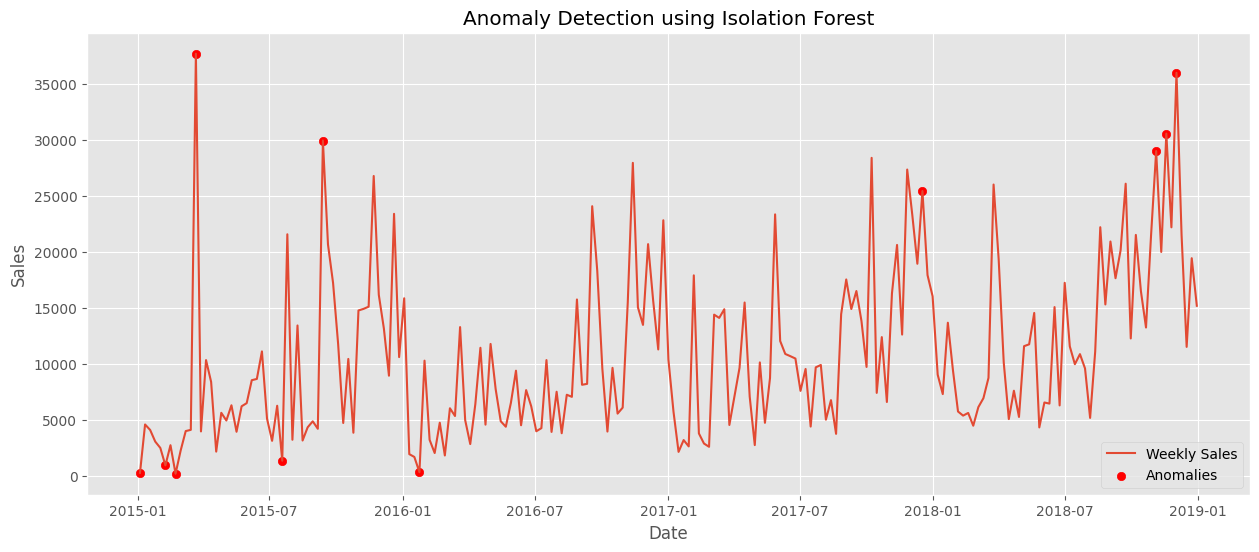

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.plot(
    weekly_sales['Order Date'],
    weekly_sales['Sales'],
    label='Weekly Sales'
)

anomalies = weekly_sales[
    weekly_sales['anomaly'] == 'Anomaly'
]

plt.scatter(
    anomalies['Order Date'],
    anomalies['Sales'],
    color='red',
    label='Anomalies'
)

plt.title("Anomaly Detection using Isolation Forest")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.show()

In [79]:
weekly_sales['rolling_mean'] = (
    weekly_sales['Sales']
    .rolling(window=4)
    .mean()
)

weekly_sales['rolling_std'] = (
    weekly_sales['Sales']
    .rolling(window=4)
    .std()
)

In [80]:
weekly_sales['z_score'] = (
    (
        weekly_sales['Sales']
        - weekly_sales['rolling_mean']
    )
    /
    weekly_sales['rolling_std']
)

In [81]:
weekly_sales['z_anomaly'] = (
    abs(weekly_sales['z_score']) > 2
)

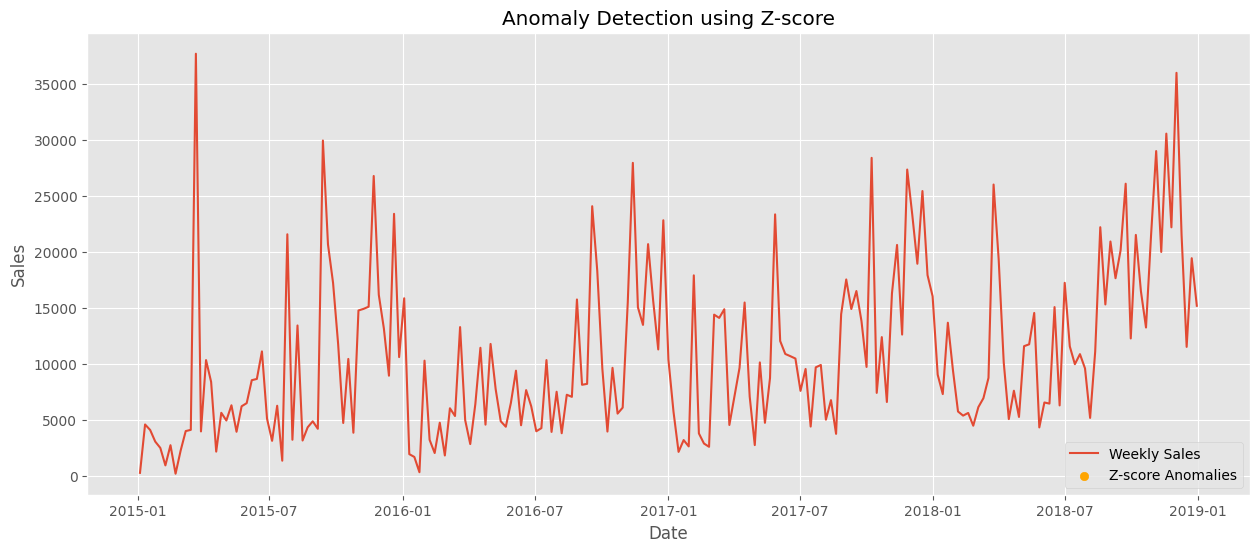

In [82]:
plt.figure(figsize=(15, 6))

plt.plot(
    weekly_sales['Order Date'],
    weekly_sales['Sales'],
    label='Weekly Sales'
)

z_anomalies = weekly_sales[
    weekly_sales['z_anomaly']
]

plt.scatter(
    z_anomalies['Order Date'],
    z_anomalies['Sales'],
    color='orange',
    label='Z-score Anomalies'
)

plt.title("Anomaly Detection using Z-score")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.show()

In [83]:
print(
    weekly_sales[
        ['Order Date',
         'Sales',
         'anomaly',
         'z_anomaly']
    ].head(20)
)

   Order Date      Sales  anomaly  z_anomaly
0  2015-01-04    304.508  Anomaly      False
1  2015-01-11   4619.108   Normal      False
2  2015-01-18   4130.533   Normal      False
3  2015-01-25   3092.544   Normal      False
4  2015-02-01   2527.914   Normal      False
5  2015-02-08    968.534  Anomaly      False
6  2015-02-15   2771.054   Normal      False
7  2015-02-22    224.912  Anomaly      False
8  2015-03-01   2289.643   Normal      False
9  2015-03-08   4030.728   Normal      False
10 2015-03-15   4139.602   Normal      False
11 2015-03-22  37703.665  Anomaly      False
12 2015-03-29   3998.777   Normal      False
13 2015-04-05  10363.902   Normal      False
14 2015-04-12   8418.293   Normal      False
15 2015-04-19   2198.370   Normal      False
16 2015-04-26   5660.104   Normal      False
17 2015-05-03   4974.812   Normal      False
18 2015-05-10   6332.464   Normal      False
19 2015-05-17   3967.870   Normal      False


In [ ]:
#Observation
Isolation Forest and Z-score methods were used to detect unusual sales patterns. Both methods identified several high-sales weeks, especially during 
festive and promotional periods. Some anomalies were detected by only one method, showing that different techniques capture different aspects of 
unusual behavior.

In [84]:
#Task 6: Product Demand Segmentation using K-Means Clustering
product_features = df.groupby('Sub-Category').agg({
    'Sales': ['sum', 'mean', 'std']
})

product_features.columns = [
    'total_sales',
    'avg_order_value',
    'sales_volatility'
]

product_features.head()

,total_sales,avg_order_value,sales_volatility
Sub-Category,,,
Accessories,164186.7000,217.178175,337.723800
Appliances,104618.4030,227.926804,378.006735
Art,26705.4100,34.019631,60.301752
Binders,200028.7850,134.067550,568.099970
Bookcases,113813.1987,503.598224,641.419280


In [85]:
yearly_sales = df.groupby(
    ['Sub-Category', df['Order Date'].dt.year]
)['Sales'].sum().unstack()

growth_rate = (
    (
        yearly_sales.iloc[:, -1]
        - yearly_sales.iloc[:, 0]
    )
    /
    yearly_sales.iloc[:, 0]
) * 100

product_features['growth_rate'] = growth_rate

In [86]:
product_features = product_features.fillna(0)

In [87]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    product_features
)

In [88]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 10):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(scaled_features)

    inertia.append(
        kmeans.inertia_
    )

C:\Users\hruth\.conda\envs\tensorflow_env\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\hruth\.conda\envs\tensorflow_env\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hruth\.conda\envs\tensorflow_env\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\hruth\.conda\envs\tensorflow_env\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMean

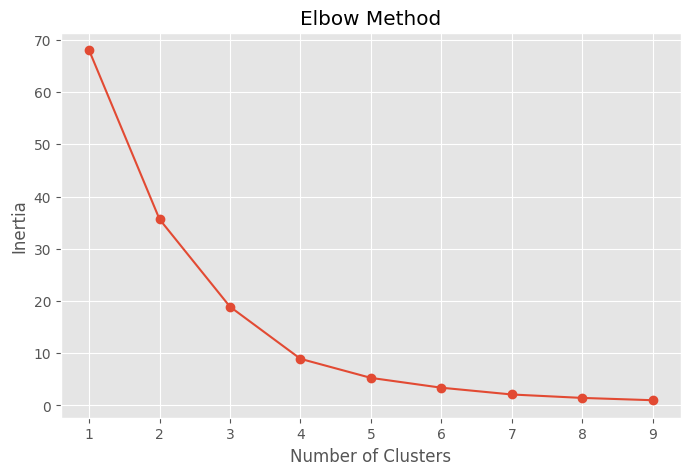

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 10),
    inertia,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.show()

In [90]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

product_features['cluster'] = kmeans.fit_predict(
    scaled_features
)

product_features.head()

C:\Users\hruth\.conda\envs\tensorflow_env\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\hruth\.conda\envs\tensorflow_env\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,total_sales,avg_order_value,sales_volatility,growth_rate,cluster
Sub-Category,,,,,
Accessories,164186.7000,217.178175,337.723800,145.055961,1
Appliances,104618.4030,227.926804,378.006735,165.242912,2
Art,26705.4100,34.019631,60.301752,49.649531,2
Binders,200028.7850,134.067550,568.099970,65.778638,1
Bookcases,113813.1987,503.598224,641.419280,49.846598,2


In [91]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2
)

pca_result = pca.fit_transform(
    scaled_features
)

product_features['PCA1'] = pca_result[:, 0]

product_features['PCA2'] = pca_result[:, 1]

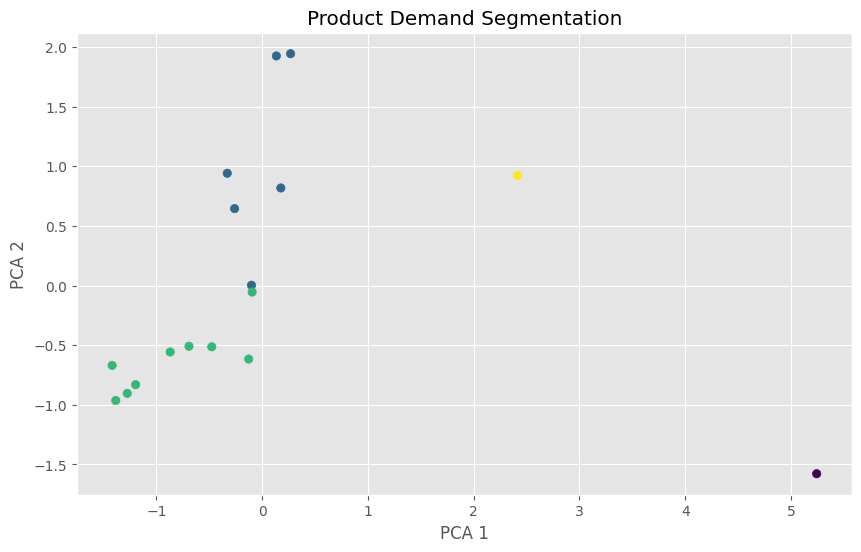

In [92]:
plt.figure(figsize=(10, 6))

plt.scatter(
    product_features['PCA1'],
    product_features['PCA2'],
    c=product_features['cluster']
)

plt.title(
    "Product Demand Segmentation"
)

plt.xlabel("PCA 1")

plt.ylabel("PCA 2")

plt.show()

In [93]:
print(
    product_features[
        ['cluster']
    ]
)

              cluster
Sub-Category         
Accessories         1
Appliances          2
Art                 2
Binders             1
Bookcases           2
Chairs              1
Copiers             0
Envelopes           2
Fasteners           2
Furnishings         2
Labels              2
Machines            3
Paper               2
Phones              1
Storage             1
Supplies            2
Tables              1


In [ ]:
#Observation
Example:

Cluster 0 contains high-volume products with stable demand patterns.

Cluster 1 represents products with high volatility and unpredictable sales.

Cluster 2 includes products with strong growth potential.

Cluster 3 consists of low-demand products that may require reduced inventory.